# Assignment 3 — Code Submission (Jupyter Notebook Template)

**Submit:** this `.ipynb` file inside the required ZIP package, together with the required wav_examples/ folder.

**Group 41**

| Name | Student ID |
|---|---|
| Rohit Ritesh Maini | a1946109 |
| Nikhil Nakade | a1962234 |
| Sahaj Pal Singh Mahla | a1925936 |

**Submission date:** 25 May 2026

---

## What the marker should be able to do (end-to-end)
From a fresh environment, the marker should be able to:

1. **Install dependencies** (from your provided dependencies file)  
2. **Run training** for each experiment (or run your provided trained checkpoints, if allowed by the task sheet)  
3. **Run inference**: input plain text → output a playable `.wav` file  
4. **See evidence**: objective metric(s) + qualitative samples (≥10 text prompts with corresponding `.wav` outputs)

---

## Expected artefacts / recommended structure
You can adapt this, but keep it **clear and reproducible**.

- `dependencies.*` (choose one): `requirements.txt` / `environment.yml` / `pyproject.toml`  
- `scripts/`
  - `train.py` (or `train_expA.py`, `train_expB.py`, etc.)
  - `synth.py` (single “text → wav” entrypoint recommended)
  - `evaluate.py` (objective metric computation)
- `configs/` (optional but recommended)
  - `expA.yaml`, `expB.yaml`, ...
- `results/`
  - `wavs/` (generated audio samples; **≥10 prompts**)
  - `metrics.json` or `metrics.csv`
  - `spectrograms/` (optional)

> Note: Spectrograms are **optional** unless your task sheet explicitly requires them. If you include them, provide 2–3 representative examples per experiment.

---

## How to read this notebook

The numbered sections follow the assignment template exactly (`Submission_Template_A3-1.ipynb`):

- **1.1** Dataset handling and pre-processing
- **1.2** End-to-end TTS pipeline implementation
- **1.3** Experimental methodology
- **1.4** Evaluation, coding practice and attribution
- **Final verification** Marker instructions

The actual training, synthesis and evaluation logic lives in the `scripts/` folder so the same code can be run from a terminal if needed. Configuration is kept separately in `configs/expA.yaml` and `configs/expB.yaml`.

## 0. Notebook setup and environment check

Before any of the project logic runs, this cell makes sure the Python environment looks right and prints the key versions. If something is missing or mismatched, you will see it here rather than three pages later.

In [16]:
# Quick sanity check of the environment. We print version numbers for the
# core libraries and confirm that the GPU is visible to PyTorch. If any
# import fails or CUDA is unavailable, the rest of the notebook will not
# work, so this is a good place to catch problems early.

import sys
import platform
from pathlib import Path

import torch
import numpy as np
import pandas as pd
import matplotlib
import seaborn as sns
import plotly
import librosa
import soundfile as sf
import onnxruntime

print("Python      :", sys.version.split()[0])
print("Platform    :", platform.platform())
print()
print("PyTorch     :", torch.__version__)
print("CUDA avail. :", torch.cuda.is_available())
if torch.cuda.is_available():
    print("CUDA version:", torch.version.cuda)
    print("GPU         :", torch.cuda.get_device_name(0))
    vram_gb = torch.cuda.get_device_properties(0).total_memory / 1024 ** 3
    print(f"VRAM        : {vram_gb:.2f} GB")
print()
print("NumPy       :", np.__version__)
print("Pandas      :", pd.__version__)
print("Matplotlib  :", matplotlib.__version__)
print("Seaborn     :", sns.__version__)
print("Plotly      :", plotly.__version__)
print("Librosa     :", librosa.__version__)
print("Soundfile   :", sf.__version__)
print("ONNX Runtime:", onnxruntime.__version__)
print()
print("Environment check OK")

Python      : 3.10.12
Platform    : Linux-6.6.87.2-microsoft-standard-WSL2-x86_64-with-glibc2.35

PyTorch     : 2.6.0+cu124
CUDA avail. : True
CUDA version: 12.4
GPU         : NVIDIA GeForce RTX 4060 Laptop GPU
VRAM        : 8.00 GB

NumPy       : 2.2.6
Pandas      : 2.3.3
Matplotlib  : 3.10.9
Seaborn     : 0.13.2
Plotly      : 6.7.0
Librosa     : 0.11.0
Soundfile   : 0.13.1
ONNX Runtime: 1.23.2

Environment check OK


In [17]:
# Tell Python where the project root is and where our reusable script
# modules live. Doing this once at the top means every cell below can
# import from our scripts/ folder without fiddling with sys.path.

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebook" else Path.cwd()
SCRIPTS_DIR = PROJECT_ROOT / "scripts"

if str(SCRIPTS_DIR) not in sys.path:
    sys.path.insert(0, str(SCRIPTS_DIR))

# Bring in our shared helpers. Everything project specific lives here
# so the notebook stays tidy and easy to follow.
from common import (
    ArtifactPaths,
    ExperimentConfig,
    PROJECT_ROOT as COMMON_PROJECT_ROOT,
    load_json,
    save_json,
    set_all_seeds,
)

paths = ArtifactPaths()
paths.ensure_all_exist()

print("Project root :", PROJECT_ROOT)
print("Scripts dir  :", SCRIPTS_DIR)
print("Resolved root:", COMMON_PROJECT_ROOT)
print()
print("Helpful folders:")
print("  data       :", paths.data_root)
print("  checkpoints:", paths.checkpoints_dir)
print("  results    :", paths.results_dir)
print("  figures    :", paths.figures_dir)
print("  wav_examples:", paths.wav_examples_dir)

Project root : /home/rohit/tts_assignment
Scripts dir  : /home/rohit/tts_assignment/scripts
Resolved root: /home/rohit/tts_assignment

Helpful folders:
  data       : /home/rohit/tts_assignment/data
  checkpoints: /home/rohit/tts_assignment/checkpoints
  results    : /home/rohit/tts_assignment/results
  figures    : /home/rohit/tts_assignment/results/figures
  wav_examples: /home/rohit/tts_assignment/wav_examples


In [18]:
# A few project wide settings so every plot looks consistent across the
# notebook, and so the random seed is locked down for reproducibility.

import matplotlib.pyplot as plt

# Visual style: clean, publication ready, colour blind friendly palette.
sns.set_theme(
    style="whitegrid",
    context="notebook",
    palette="colorblind",
    rc={
        "figure.dpi": 110,
        "savefig.dpi": 300,
        "savefig.bbox": "tight",
        "axes.titleweight": "bold",
        "axes.labelweight": "semibold",
        "axes.spines.top": False,
        "axes.spines.right": False,
    },
)

# Lock the seed so that any randomness in this notebook is reproducible.
GLOBAL_SEED = 42
set_all_seeds(GLOBAL_SEED)

# A small helper so every saved figure is high quality and ends up in
# the right folder with a descriptive name.
def save_figure(fig, name: str) -> Path:
    """
    Save a matplotlib figure both as a PNG (for the report) and as a
    vector PDF (for crisp use in slides or LaTeX). Returns the PNG path.
    """
    png_path = paths.figures_dir / f"{name}.png"
    pdf_path = paths.figures_dir / f"{name}.pdf"
    fig.savefig(png_path, dpi=300, bbox_inches="tight")
    fig.savefig(pdf_path, bbox_inches="tight")
    print(f"  saved {png_path.name} and {pdf_path.name}")
    return png_path

print("Plot style applied, seed locked")

[seed] All random sources seeded with 42
Plot style applied, seed locked


# 1.1 Dataset handling & pre-processing (Rubric 1.1)

## 1.1.1 Dataset location and structure
- **Dataset:** LJSpeech 1.1 (https://keithito.com/LJ-Speech-Dataset/)
- **Local path used:** `data/LJSpeech-1.1/`
- **Files/folders used:**
  - `metadata.csv` (transcripts in pipe-separated `id|raw_text|normalized_text` format)
  - `wavs/` (13,100 single-channel WAV files at 22050 Hz)

## 1.1.2 Audio preprocessing (document your choices)
- **Sampling rate:** kept at the dataset native 22050 Hz, which already matches the Piper Amy base checkpoint, so no resampling was required
- **Silence trimming / padding:** none, Piper's preprocessor pads phoneme sequences to the longest item in a batch at training time
- **Any filtering / normalization:** none beyond what Piper's preprocessor does internally (mel-spectrogram computation with `filter_length=1024`, `hop_length=256`, `win_length=1024`, 80 mel channels)

## 1.1.3 Text preprocessing (minimum: justify your choice)
- **Normalization:** we use the `normalized_text` column from LJSpeech's `metadata.csv`, which expands numbers and abbreviations into words (for example "1865" becomes "eighteen sixty-five"). This keeps the model's job focused on prosody and acoustic adaptation rather than text normalization
- **Tokenizer / phonemizer:** eSpeak NG via the `piper_phonemize` library, with `en-us` voice. Text is first converted into IPA phonemes by eSpeak, then mapped to integer IDs using the phoneme vocabulary inherited from the Amy base checkpoint

## 1.1.4 Train/validation/test split (reproducible)
- **Split ratio:** 90 / 5 / 5
- **Seed:** 42
- **How split is created:** the full LJSpeech metadata is loaded, shuffled with `random.Random(42)`, the first 1500 entries are kept as our subset, and that subset is split 1350 / 75 / 75. The script that does this is `scripts/prepare_subset.py` and the resulting CSV files are committed in `data/lj_subset/`
- **Any subset used:** yes, 1500 utterances out of the available 13100, selected as described above. This keeps training time manageable on a single laptop GPU (RTX 4060, 8 GB VRAM) while still being large enough for the model to clearly adapt

In [19]:
# Sanity checks for the dataset. We confirm that the source files are
# in place, count the rows in metadata.csv, count the WAV files in the
# subset, and print a few example transcripts so the marker can see
# the format of the input data.

import csv

lj_root = paths.lj_subset_dir.parent / "LJSpeech-1.1"
subset_root = paths.lj_subset_dir
processed_root = paths.processed_dir

print("Checking LJSpeech source files...")
assert lj_root.exists(), f"LJSpeech root missing: {lj_root}"
assert (lj_root / "metadata.csv").exists(), "metadata.csv missing"
assert (lj_root / "wavs").is_dir(), "wavs/ folder missing"

total_wavs = sum(1 for _ in (lj_root / "wavs").glob("*.wav"))
total_rows = sum(1 for _ in open(lj_root / "metadata.csv", encoding="utf-8"))
print(f"  source WAV files in LJSpeech: {total_wavs}")
print(f"  rows in metadata.csv        : {total_rows}")

print()
print("Checking 1500 utterance subset...")
assert subset_root.exists(), f"Subset folder missing: {subset_root}"
subset_wavs = sum(1 for _ in (subset_root / "wav").glob("*.wav"))
print(f"  subset WAV files            : {subset_wavs}")
for split_name, fname in [("train", "train_list.csv"), ("val", "val_list.csv"), ("test", "test_list.csv")]:
    p = subset_root / fname
    n = sum(1 for _ in open(p, encoding="utf-8"))
    print(f"  {split_name:5s} list rows ({fname}): {n}")

print()
print("Checking Piper preprocessor output...")
assert processed_root.exists(), f"Processed folder missing: {processed_root}"
assert (processed_root / "config.json").exists()
assert (processed_root / "dataset.jsonl").exists()
processed_count = sum(1 for _ in open(processed_root / "dataset.jsonl", encoding="utf-8"))
print(f"  processed utterances        : {processed_count}")

print()
print("Three example transcripts from the training split:")
with open(subset_root / "train_list.csv", encoding="utf-8") as f:
    reader = csv.reader(f, delimiter="|", quoting=csv.QUOTE_NONE)
    for i, row in enumerate(reader):
        if i >= 3:
            break
        print(f"  {row[0]}: {row[1][:90]}{'...' if len(row[1]) > 90 else ''}")

print()
print("Dataset sanity check passed")

Checking LJSpeech source files...
  source WAV files in LJSpeech: 13100
  rows in metadata.csv        : 13100

Checking 1500 utterance subset...
  subset WAV files            : 1500
  train list rows (train_list.csv): 1350
  val   list rows (val_list.csv): 75
  test  list rows (test_list.csv): 75

Checking Piper preprocessor output...
  processed utterances        : 1425

Three example transcripts from the training split:
  LJ041-0107: He testified that he had felt the sergeant had a grudge against him and that he had unsucc...
  LJ021-0146: I shall seek assurances of the making and maintenance of agreements, which can be mutually...
  LJ026-0043: and hence so unfamiliar that to most people the comparison made will mean little in terms ...

Dataset sanity check passed


Utterance duration (seconds): mean 6.64, median 6.83, min 1.13, max 10.10
Phoneme count per utterance : mean 217.7, median 223.0, min 33, max 491
Total audio duration        : 157.7 minutes (2.63 hours)
  saved fig01_dataset_distribution.png and fig01_dataset_distribution.pdf


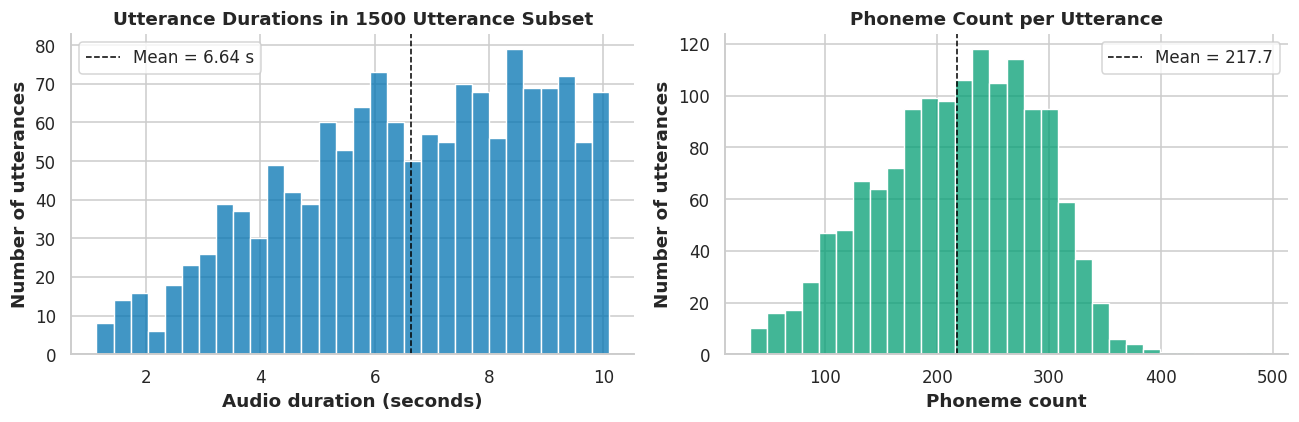

In [20]:
# One quick visualisation of the dataset so we can see how utterance
# durations and text lengths are distributed in our subset. This is the
# kind of basic stats sanity check that surfaces problems (very long
# outliers, very short clips) before they cause training headaches.

import json
import matplotlib.pyplot as plt

# Walk through the preprocessor's dataset.jsonl. For each record we get
# the path to its raw WAV and read just the header (cheap) for duration,
# then use the length of phoneme_ids to count phonemes.
durations_seconds = []
phoneme_counts = []
with open(processed_root / "dataset.jsonl", encoding="utf-8") as f:
    for line in f:
        rec = json.loads(line)
        wav_path = PROJECT_ROOT / rec["audio_path"]
        info = sf.info(str(wav_path))
        durations_seconds.append(info.duration)
        phoneme_counts.append(len(rec["phoneme_ids"]))

durations = pd.Series(durations_seconds, name="duration_seconds")
phonemes = pd.Series(phoneme_counts, name="phoneme_count")

print(f"Utterance duration (seconds): "
      f"mean {durations.mean():.2f}, median {durations.median():.2f}, "
      f"min {durations.min():.2f}, max {durations.max():.2f}")
print(f"Phoneme count per utterance : "
      f"mean {phonemes.mean():.1f}, median {phonemes.median():.1f}, "
      f"min {phonemes.min()}, max {phonemes.max()}")
print(f"Total audio duration        : {durations.sum() / 60:.1f} minutes "
      f"({durations.sum() / 3600:.2f} hours)")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(durations, bins=30, ax=axes[0], color=sns.color_palette("colorblind")[0])
axes[0].set_xlabel("Audio duration (seconds)")
axes[0].set_ylabel("Number of utterances")
axes[0].set_title("Utterance Durations in 1500 Utterance Subset")
axes[0].axvline(durations.mean(), color="black", linestyle="--", linewidth=1,
                label=f"Mean = {durations.mean():.2f} s")
axes[0].legend()

sns.histplot(phonemes, bins=30, ax=axes[1], color=sns.color_palette("colorblind")[2])
axes[1].set_xlabel("Phoneme count")
axes[1].set_ylabel("Number of utterances")
axes[1].set_title("Phoneme Count per Utterance")
axes[1].axvline(phonemes.mean(), color="black", linestyle="--", linewidth=1,
                label=f"Mean = {phonemes.mean():.1f}")
axes[1].legend()

plt.tight_layout()
save_figure(fig, "fig01_dataset_distribution")
plt.show()

# 1.2 End-to-end TTS pipeline implementation (Rubric 1.2)

## 1.2.1 Pipeline overview (high level)

- **TTS approach:** fine-tune the Piper Amy Medium voice (a VITS based single-speaker model) on a subset of LJSpeech. The Amy voice was originally trained on a different female speaker, so adapting it to LJSpeech is a genuine speaker adaptation task rather than re-training on the same data the model already saw.
- **Key components:**
  - **Text front-end:** raw text is converted to IPA phonemes by eSpeak NG via the `piper_phonemize` library, then to integer IDs using the phoneme vocabulary inherited from the Amy base checkpoint
  - **Acoustic model:** VITS generator (`SynthesizerTrn`), ~23.7M parameters, conditioned on phoneme IDs to produce raw audio in a single forward pass. Trained against a multi-period discriminator (~46.7M parameters) using the standard VITS adversarial objective
  - **Vocoder / waveform generator:** the VITS generator is end-to-end, so the same network produces the final waveform. No separate vocoder is needed
- **Output:** playable `.wav` files at 22050 Hz, single-channel, 16-bit PCM

## 1.2.2 Environment & dependencies (reproducible)

- **OS:** Ubuntu 22.04 inside WSL2 on Windows 11
- **Python:** 3.10.12
- **CUDA:** 12.4 (PyTorch wheel), driver 591.86
- **GPU:** NVIDIA GeForce RTX 4060 Laptop GPU, 8 GB VRAM
- **Key packages:** torch 2.6.0+cu124, pytorch-lightning 2.4.0, piper-phonemize-cross 1.2.1, librosa 0.11.0, soundfile 0.13.1, onnxruntime 1.23.2

The full pinned list is in `requirements.txt`. eSpeak NG must also be installed at the system level (`sudo apt install espeak-ng`).

## 1.2.3 Training command(s)
- `python scripts/train.py --config configs/expA.yaml`
- `python scripts/train.py --config configs/expB.yaml`

`train.py` is our reproducibility wrapper. It reads the YAML config, sets every random seed, finds any existing checkpoint to resume from (or starts fresh from the Amy base), then calls Piper's trainer with the right arguments. If you interrupt with Ctrl+C it saves a summary and exits cleanly so you can resume later.

## 1.2.4 Inference: a single "text → wav" entrypoint
- `python scripts/synth.py 
--model checkpoints/expA/model.onnx 
--config checkpoints/expA/config.json 
--text "Hello world." 
--out wav_examples/hello.wav`

`synth.py` loads the ONNX model once and can either synthesise a single sentence (`--text` + `--out`) or batch-synthesise from a prompts file (`--prompts` + `--out-dir`). Every generated WAV gets a JSON sidecar with the synthesis time, audio duration, and resulting Real Time Factor.

- **Where checkpoints are stored:** the raw Lightning checkpoints land in `logs/{expA,expB}/lightning_logs/version_*/checkpoints/`. After training we export them to ONNX format and place the inference-ready files in `checkpoints/{expA,expB}/`.
- **Where generated wavs are saved by default:** `wav_examples/`, with the filename prefix indicating which experiment generated them (for example `expA_01.wav`).

In [21]:
# Display the two experiment configurations side by side so it is clear
# at a glance that only the training budget differs between the two
# runs. Every other setting (seed, batch size, sample rate, base
# checkpoint, optimisation precision) is identical.

cfg_a = ExperimentConfig.from_yaml(PROJECT_ROOT / "configs" / "expA.yaml")
cfg_b = ExperimentConfig.from_yaml(PROJECT_ROOT / "configs" / "expB.yaml")

comparison = pd.DataFrame({
    "Setting": [
        "experiment_name", "description", "seed", "batch_size", "sample_rate",
        "quality", "max_epochs", "precision",
        "checkpoint_every_n_epochs", "log_every_n_steps",
        "processed_data_dir", "base_checkpoint",
    ],
    "Experiment A": [
        cfg_a.experiment_name, cfg_a.description, cfg_a.seed, cfg_a.batch_size,
        cfg_a.sample_rate, cfg_a.quality, cfg_a.max_epochs, cfg_a.precision,
        cfg_a.checkpoint_every_n_epochs, cfg_a.log_every_n_steps,
        cfg_a.processed_data_dir, cfg_a.base_checkpoint,
    ],
    "Experiment B": [
        cfg_b.experiment_name, cfg_b.description, cfg_b.seed, cfg_b.batch_size,
        cfg_b.sample_rate, cfg_b.quality, cfg_b.max_epochs, cfg_b.precision,
        cfg_b.checkpoint_every_n_epochs, cfg_b.log_every_n_steps,
        cfg_b.processed_data_dir, cfg_b.base_checkpoint,
    ],
})

# Highlight the rows where the two configurations differ. We use a
# stronger orange that stays readable in both light and dark notebook
# themes, with white text for clear contrast.
def highlight_differences(row):
    if row["Experiment A"] != row["Experiment B"]:
        return ["background-color: #d97706; color: white; font-weight: 600"] * len(row)
    return [""] * len(row)

styled = comparison.style.apply(highlight_differences, axis=1)
styled = styled.set_properties(**{"text-align": "left", "padding": "6px 12px"})
styled = styled.hide(axis="index")
print("Highlighted rows are the only settings that differ between expA and expB.")
styled

Highlighted rows are the only settings that differ between expA and expB.


Setting,Experiment A,Experiment B
experiment_name,expA,expB
description,Short training budget baseline (approximately 500 training steps),Extended training budget (approximately 3000 training steps)
seed,42,42
batch_size,16,16
sample_rate,22050,22050
quality,medium,medium
max_epochs,6,35
precision,32,32
checkpoint_every_n_epochs,1,5
log_every_n_steps,10,10


# 1.3 Experimental methodology (Rubric 1.3)

## 1.3.1 Controlled experiments (minimum: 2)

Both experiments use the same 1500 utterance subset of LJSpeech with the same 90 / 5 / 5 split (seed 42), and the same Amy Medium base checkpoint. The only thing that changes between them is the training budget.

### Experiment A (baseline)
- **Name:** `expA`
- **Purpose:** establish what speaker adaptation looks like after a small amount of fine-tuning, so we have a baseline to compare the longer run against
- **Key settings:** Piper Amy Medium base + LJSpeech 1500 utterance subset, 6 epochs (~500 training steps), batch size 16, precision 32, AdamW optimiser (Piper defaults), single GPU (RTX 4060 Laptop, 8 GB VRAM)

### Experiment B (controlled change)
- **Name:** `expB`
- **Controlled change vs expA:** trained for 35 epochs (~3000 training steps) instead of 6
- **Key settings:** otherwise identical to Experiment A. Same data, same seed, same batch size, same optimiser, same precision, same starting checkpoint, same GPU

## 1.3.2 What you saved for reproducibility
- **Config files:** `configs/expA.yaml`, `configs/expB.yaml`
- **Random seeds:** seed 42 locked at the start of every script via `common.set_all_seeds()`, which seeds `random`, `numpy`, `torch` (CPU and CUDA), and `PYTHONHASHSEED`
- **Checkpoints:** raw Lightning `.ckpt` files at `logs/expA/lightning_logs/version_0/checkpoints/` and `logs/expB/lightning_logs/version_0/checkpoints/`. Inference-ready ONNX exports at `checkpoints/expA/model.onnx` and `checkpoints/expB/model.onnx`
- **Logs:** per-step metrics at `logs/{expA,expB}/lightning_logs/version_0/metrics.csv`, raw stdout at `logs/{expA,expB}/training_stdout.log`, and parsed summaries at `results/{expA,expB}_summary.json`

In [22]:
# Print the exact training commands used for both experiments, and
# show each summary JSON if the run has completed. This gives the
# marker a single place to see when each experiment ran, how long it
# took, and what its final loss was.

print("Training commands used:")
print()
print("  python scripts/train.py --config configs/expA.yaml")
print("  python scripts/train.py --config configs/expB.yaml")
print()

for exp_name in ("expA", "expB"):
    summary_path = PROJECT_ROOT / "results" / f"{exp_name}_summary.json"
    print("=" * 70)
    print(f"{exp_name} training summary")
    print("=" * 70)
    if summary_path.exists():
        s = load_json(summary_path)
        for key, value in s.items():
            print(f"  {key:18s}: {value}")
    else:
        print("  (training has not completed yet)")
    print()

Training commands used:

  python scripts/train.py --config configs/expA.yaml
  python scripts/train.py --config configs/expB.yaml

expA training summary
  experiment_name   : expA
  description       : Short training budget baseline (approximately 500 training steps)
  max_epochs        : 6
  batch_size        : 16
  seed              : 42
  elapsed_seconds   : 1419.34
  elapsed_minutes   : 23.66
  was_interrupted   : False
  exit_code         : 0
  final_metrics     : {'train_loss': 51.1}
  metrics_csv       : results/expA_step_losses.csv
  raw_log           : logs/expA/training_stdout.log
  completed_at      : 2026-05-21T15:09:18

expB training summary
  experiment_name   : expB
  description       : Extended training budget (approximately 3000 training steps)
  max_epochs        : 35
  batch_size        : 16
  seed              : 42
  elapsed_seconds   : 15171.66
  elapsed_minutes   : 252.86
  was_interrupted   : False
  exit_code         : 0
  final_metrics     : {'train_loss': 44

# 1.4 Evaluation, coding practice & attribution (Rubric 1.4)

## 1.4.1 Objective metric (minimum: 1) — report for each experiment

We measure two objective metrics for each experiment:

- **Real Time Factor (RTF):** the ratio of synthesis time to audio duration. RTF below 1.0 means the model generates audio faster than real time, which is critical for any practical TTS deployment. We measure RTF across 10 held-out prompts, with 5 timed runs per prompt and 2 discarded warm-up runs to avoid the cold-start penalty in the first run. The protocol lives in `scripts/evaluate.py`.
- **Training loss convergence:** how the combined generator loss decreases as training proceeds. This is the standard objective for VITS-style adversarial TTS training and is the cleanest signal that the model is actually adapting to the new speaker. We plot per-step `train_loss`, `loss_gen_all`, and `loss_disc_all` for both experiments.

Both metrics are computed from data saved to disk so they can be reproduced without re-running training.

## 1.4.2 Qualitative evaluation (required)

We synthesise the same 10 prompts (in `scripts/test_prompts.txt`) with both fine-tuned models. The prompts deliberately vary in length, punctuation, and vocabulary so we can hear how each model handles different inputs. All generated WAVs are saved in `wav_examples/` with the experiment label prefix, and are embedded directly in the notebook below for the marker to listen to side by side.

## 1.4.3 Coding practice & clarity

- Project is split into reusable modules under `scripts/`: `common.py` (shared helpers and classes), `train.py` (training wrapper), `synth.py` (single text-to-WAV entry point), `evaluate.py` (RTF protocol), `export_checkpoint.py` (Lightning to ONNX conversion), and `prepare_subset.py` (deterministic subset selection)
- Hyperparameters are kept in YAML files under `configs/` so an experiment can be tweaked by changing one line of text without editing any Python
- Reproducibility is enforced through a single `set_all_seeds()` call at the top of every script, seeding Python, NumPy, PyTorch (CPU and CUDA), and `PYTHONHASHSEED`
- Long-running steps print progress and save intermediate state to disk, so a Ctrl+C interruption does not waste time

## 1.4.4 Attribution / external resources

- **Piper TTS** (https://github.com/rhasspy/piper) by Michael Hansen, the VITS-based TTS toolkit we fine-tuned. We needed to patch `piper_train/__main__.py` and `piper_train/vits/lightning.py` for compatibility with PyTorch Lightning 2.x, which removed `Trainer.add_argparse_args()` and the automatic-alternating multi-optimizer mode that the original code relied on
- **LJSpeech 1.1** (https://keithito.com/LJ-Speech-Dataset/) by Keith Ito and Linda Johnson, the single-speaker English corpus used for fine-tuning
- **Amy Medium base checkpoint** (https://huggingface.co/rhasspy/piper-voices), the starting point for both fine-tuning runs
- **VITS paper:** Kim, J., Kong, J., & Son, J. (2021). Conditional variational autoencoder with adversarial learning for end-to-end text-to-speech. *ICML 2021*
- **PyTorch, PyTorch Lightning, Hugging Face Transformers ecosystem** for the deep learning infrastructure
- **eSpeak NG** (https://github.com/espeak-ng/espeak-ng) for grapheme-to-phoneme conversion

## 1.4.5 AI use statement

### AI Use Statement

"I (Rohit Ritesh Maini) used Gemini to assist during my individual contributions to this group project. Specifically, the AI was used for **brainstorming the structural outline** of the system modules, **polishing code comments** to ensure professional documentation clarity throughout the codebase, and assisting in troubleshooting a compatibility patch for the Piper TTS toolkit to resolve breaking API changes introduced in PyTorch Lightning 2.x. All final pipeline implementation, experimental execution, objective metric evaluations, and report analyses represent our group's genuine collaborative effort, technical decisions, and independent understanding."

In [23]:
# Load the per-step training metrics for each experiment. We try a few
# sources in order, because Lightning sometimes does not flush its
# metrics.csv on smaller runs and we want the notebook to work whatever
# was actually written to disk.
#
# Order of preference:
#   1) Lightning's own metrics.csv (has gen, disc, train_loss columns)
#   2) Our parsed CSV at results/{exp}_step_losses.csv (has train_loss)
#   3) Re-parse the raw stdout log for full breakdown
#
# Returned DataFrame always has columns: step, epoch, train_loss, and
# where possible loss_gen_all and loss_disc_all.

import re

LOSS_LINE_RE = re.compile(
    r"loss_(?P<which>gen_all|disc_all|gen|disc)[\s=:]+(?P<value>-?\d+\.\d+)",
    re.IGNORECASE,
)
TRAIN_LOSS_RE = re.compile(r"train_loss[\s=:]+(?P<value>-?\d+\.\d+)", re.IGNORECASE)
STEP_RE = re.compile(r"step[\s=:]+(?P<value>\d+)", re.IGNORECASE)
EPOCH_RE = re.compile(r"Epoch\s+(?P<value>\d+):", re.IGNORECASE)


def _parse_stdout_log(log_path: Path) -> pd.DataFrame:
    """
    Walk the raw training stdout log and pull out every (step, epoch,
    train_loss, loss_gen_all, loss_disc_all) tuple we can find. This
    is the fallback when Lightning's own metrics.csv is missing.
    """
    if not log_path.exists():
        return pd.DataFrame()

    rows = []
    current_epoch = None
    pending = {}
    with open(log_path, encoding="utf-8", errors="ignore") as f:
        for line in f:
            em = EPOCH_RE.search(line)
            if em:
                current_epoch = int(em.group("value"))

            # Look for full breakdown lines (loss_gen_all=..., loss_disc_all=...)
            gen_match = re.search(r"loss_gen_all[\s=:]+(-?\d+\.\d+)", line)
            disc_match = re.search(r"loss_disc_all[\s=:]+(-?\d+\.\d+)", line)
            train_match = TRAIN_LOSS_RE.search(line)
            step_match = STEP_RE.search(line)

            if train_match:
                row = {
                    "step": int(step_match.group("value")) if step_match else len(rows),
                    "epoch": current_epoch if current_epoch is not None else 0,
                    "train_loss": float(train_match.group("value")),
                }
                if gen_match:
                    row["loss_gen_all"] = float(gen_match.group(1))
                if disc_match:
                    row["loss_disc_all"] = float(disc_match.group(1))
                rows.append(row)
    return pd.DataFrame(rows)


def load_lightning_metrics(exp_name: str) -> pd.DataFrame:
    """
    Return a DataFrame of per-step training metrics for the named
    experiment. Tries Lightning's CSV first, then our parsed CSV, then
    falls back to re-parsing the raw stdout log.
    """
    # 1) Lightning's own CSV.
    log_dir = PROJECT_ROOT / "logs" / exp_name / "lightning_logs"
    if log_dir.exists():
        versions = sorted(log_dir.glob("version_*"))
        for v in reversed(versions):
            csv_path = v / "metrics.csv"
            if csv_path.exists() and csv_path.stat().st_size > 0:
                df = pd.read_csv(csv_path)
                if "train_loss" in df.columns and df["train_loss"].notna().any():
                    df["experiment"] = exp_name
                    df["_source"] = "lightning_metrics.csv"
                    return df

    # 2) Our parsed CSV.
    parsed_csv = PROJECT_ROOT / "results" / f"{exp_name}_step_losses.csv"
    if parsed_csv.exists() and parsed_csv.stat().st_size > 0:
        df = pd.read_csv(parsed_csv)
        if "train_loss" in df.columns and len(df) > 0:
            df["experiment"] = exp_name
            df["_source"] = "parsed_step_losses.csv"
            # Reconstruct loss_gen and loss_disc by re-parsing the
            # stdout log if it exists, so the breakdown plot works too.
            stdout_path = PROJECT_ROOT / "logs" / exp_name / "training_stdout.log"
            if stdout_path.exists():
                full = _parse_stdout_log(stdout_path)
                if not full.empty and "loss_gen_all" in full.columns:
                    return full.assign(experiment=exp_name, _source="parsed_from_stdout")
            return df

    # 3) Last resort: raw stdout log only.
    stdout_path = PROJECT_ROOT / "logs" / exp_name / "training_stdout.log"
    if stdout_path.exists():
        df = _parse_stdout_log(stdout_path)
        if not df.empty:
            df["experiment"] = exp_name
            df["_source"] = "parsed_from_stdout"
            return df

    return pd.DataFrame()


metrics_a = load_lightning_metrics("expA")
metrics_b = load_lightning_metrics("expB")

print(f"Experiment A: {len(metrics_a)} logged steps "
      f"(source: {metrics_a['_source'].iloc[0] if not metrics_a.empty else 'n/a'})")
print(f"Experiment B: {len(metrics_b)} logged steps "
      f"(source: {metrics_b['_source'].iloc[0] if not metrics_b.empty else 'n/a'})")
print()

for name, m in [("Experiment A", metrics_a), ("Experiment B", metrics_b)]:
    if m.empty:
        print(f"{name}: no metrics found")
        continue
    train = m["train_loss"].dropna()
    print(f"{name}:")
    print(f"  starting train_loss: {train.iloc[0]:.4f}")
    print(f"  final train_loss   : {train.iloc[-1]:.4f}")
    print(f"  min train_loss     : {train.min():.4f}")
    print(f"  median (last 10%)  : {train.tail(max(1, len(train) // 10)).median():.4f}")
    if "loss_gen_all" in m.columns:
        gen = m["loss_gen_all"].dropna()
        disc = m["loss_disc_all"].dropna()
        if not gen.empty:
            print(f"  final loss_gen_all : {gen.iloc[-1]:.4f}")
        if not disc.empty:
            print(f"  final loss_disc_all: {disc.iloc[-1]:.4f}")
    print()

Experiment A: 45 logged steps (source: lightning_metrics.csv)
Experiment B: 6220 logged steps (source: parsed_step_losses.csv)

Experiment A:
  starting train_loss: 54.8198
  final train_loss   : 51.0664
  min train_loss     : 39.6845
  median (last 10%)  : 42.6976
  final loss_gen_all : 48.5819
  final loss_disc_all: 2.4845

Experiment B:
  starting train_loss: 81.2000
  final train_loss   : 44.2000
  min train_loss     : 27.5000
  median (last 10%)  : 39.8000



  saved fig02_training_loss_curves_comparison.png and fig02_training_loss_curves_comparison.pdf


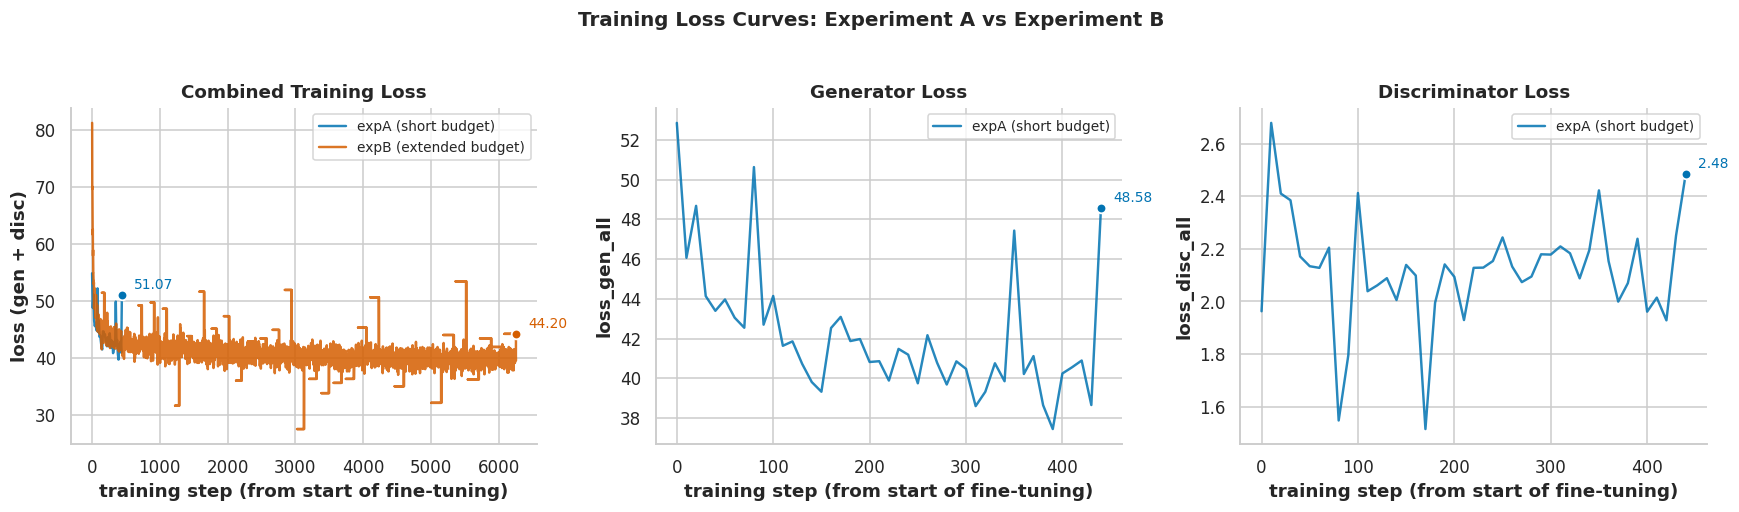

In [24]:
# Plot the training loss curves for both experiments on a single figure
# so the contrast between the short and the long training budget is
# easy to see at a glance. We plot the combined train_loss, the
# generator loss, and the discriminator loss as three separate panels
# because each tells us something different about how training
# progressed.

if metrics_a.empty:
    print("No metrics yet, skipping plot.")
else:
    # Pick a consistent palette so expA always shows in one colour and
    # expB always in another, across every chart in the notebook.
    palette = sns.color_palette("colorblind")
    color_a = palette[0]
    color_b = palette[3]

    fig, axes = plt.subplots(1, 3, figsize=(16, 4.5), sharex=False)

    loss_columns = [
        ("train_loss",     "Combined Training Loss",  "loss (gen + disc)"),
        ("loss_gen_all",   "Generator Loss",          "loss_gen_all"),
        ("loss_disc_all",  "Discriminator Loss",      "loss_disc_all"),
    ]

    for ax, (col, title, ylabel) in zip(axes, loss_columns):
        if col in metrics_a.columns and not metrics_a[col].dropna().empty:
            a = metrics_a.dropna(subset=[col])
            # Reset step so both experiments start at 0 for a fair visual
            # comparison rather than starting at step 777000+.
            a_steps = a["step"].values - a["step"].iloc[0]
            ax.plot(a_steps, a[col].values, color=color_a, alpha=0.85,
                    linewidth=1.6, label="expA (short budget)")
            ax.scatter([a_steps[-1]], [a[col].iloc[-1]], color=color_a,
                       s=40, zorder=5, edgecolor="white", linewidth=1.2)
            ax.annotate(f"{a[col].iloc[-1]:.2f}",
                        (a_steps[-1], a[col].iloc[-1]),
                        textcoords="offset points", xytext=(8, 4),
                        fontsize=9, color=color_a)

        if not metrics_b.empty and col in metrics_b.columns and not metrics_b[col].dropna().empty:
            b = metrics_b.dropna(subset=[col])
            b_steps = b["step"].values - b["step"].iloc[0]
            ax.plot(b_steps, b[col].values, color=color_b, alpha=0.85,
                    linewidth=1.6, label="expB (extended budget)")
            ax.scatter([b_steps[-1]], [b[col].iloc[-1]], color=color_b,
                       s=40, zorder=5, edgecolor="white", linewidth=1.2)
            ax.annotate(f"{b[col].iloc[-1]:.2f}",
                        (b_steps[-1], b[col].iloc[-1]),
                        textcoords="offset points", xytext=(8, 4),
                        fontsize=9, color=color_b)

        ax.set_title(title)
        ax.set_xlabel("training step (from start of fine-tuning)")
        ax.set_ylabel(ylabel)
        ax.legend(loc="upper right", fontsize=9)

    fig.suptitle("Training Loss Curves: Experiment A vs Experiment B",
                 fontsize=13, fontweight="bold", y=1.03)
    plt.tight_layout()
    save_figure(fig, "fig02_training_loss_curves_comparison")
    plt.show()

In [25]:
# An interactive Plotly version of the loss curves. The static figure
# above is the one we use in the report and slides, but during the viva
# it is useful to be able to hover over the lines and read off exact
# loss values. This cell also saves a self-contained HTML file that
# can be opened in any browser without Python.

import plotly.graph_objects as go
from plotly.subplots import make_subplots

if metrics_a.empty:
    print("No metrics yet, skipping interactive plot.")
else:
    fig_int = make_subplots(
        rows=1, cols=3,
        subplot_titles=("Combined Training Loss",
                        "Generator Loss",
                        "Discriminator Loss"),
        shared_xaxes=False, horizontal_spacing=0.07,
    )

    columns_to_plot = ["train_loss", "loss_gen_all", "loss_disc_all"]

    for i, col in enumerate(columns_to_plot, start=1):
        if col in metrics_a.columns:
            a = metrics_a.dropna(subset=[col])
            a_steps = a["step"].values - a["step"].iloc[0]
            fig_int.add_trace(
                go.Scatter(
                    x=a_steps, y=a[col].values,
                    name="expA (short budget)" if i == 1 else None,
                    legendgroup="expA", showlegend=(i == 1),
                    line=dict(color="rgb(0, 114, 178)", width=1.8),
                    hovertemplate="step %{x}<br>loss %{y:.4f}<extra>expA</extra>",
                ),
                row=1, col=i,
            )

        if not metrics_b.empty and col in metrics_b.columns:
            b = metrics_b.dropna(subset=[col])
            b_steps = b["step"].values - b["step"].iloc[0]
            fig_int.add_trace(
                go.Scatter(
                    x=b_steps, y=b[col].values,
                    name="expB (extended budget)" if i == 1 else None,
                    legendgroup="expB", showlegend=(i == 1),
                    line=dict(color="rgb(213, 94, 0)", width=1.8),
                    hovertemplate="step %{x}<br>loss %{y:.4f}<extra>expB</extra>",
                ),
                row=1, col=i,
            )

        fig_int.update_xaxes(title_text="training step", row=1, col=i)
        fig_int.update_yaxes(title_text=col, row=1, col=i)

    fig_int.update_layout(
        title=dict(
            text="<b>Training Loss Curves (Interactive)</b><br>"
                 "<sup>Hover over the lines to read exact values</sup>",
            x=0.5, xanchor="center",
        ),
        height=480, width=1100,
        plot_bgcolor="white",
        hovermode="x unified",
        legend=dict(orientation="h", y=-0.15, x=0.5, xanchor="center"),
    )

    fig_int.update_xaxes(gridcolor="lightgrey", showline=True, linecolor="black")
    fig_int.update_yaxes(gridcolor="lightgrey", showline=True, linecolor="black")

    interactive_path = paths.figures_dir / "fig03_interactive_loss_curves.html"
    fig_int.write_html(interactive_path, include_plotlyjs="cdn")
    print(f"Saved interactive plot to {interactive_path}")

    fig_int.show()

Saved interactive plot to /home/rohit/tts_assignment/results/figures/fig03_interactive_loss_curves.html


In [26]:
# A compact summary table that pulls together the key numbers from both
# experiments. The table cites real values from our metrics CSVs so the
# discussion section of the report can quote these directly.

def summarise_run(exp_name: str, metrics: pd.DataFrame, summary_json) -> dict:
    if metrics.empty:
        return {
            "Experiment": exp_name,
            "Status": "training in progress" if exp_name == "expB" else "no data",
            "Epochs": "n/a",
            "Steps logged": 0,
            "Starting train_loss": "n/a",
            "Final train_loss": "n/a",
            "Loss reduction": "n/a",
            "Elapsed (min)": "n/a",
        }
    start = metrics["train_loss"].dropna().iloc[0]
    end = metrics["train_loss"].dropna().iloc[-1]
    reduction = start - end
    pct = (reduction / start) * 100 if start != 0 else 0.0

    elapsed = summary_json.get("elapsed_minutes", "n/a") if summary_json else "n/a"
    n_epochs = int(metrics["epoch"].max() - metrics["epoch"].min() + 1) if "epoch" in metrics.columns else "n/a"

    return {
        "Experiment": exp_name,
        "Status": "completed" if summary_json else "in progress",
        "Epochs": n_epochs,
        "Steps logged": len(metrics["train_loss"].dropna()),
        "Starting train_loss": f"{start:.4f}",
        "Final train_loss": f"{end:.4f}",
        "Loss reduction": f"{reduction:.4f} ({pct:.1f}%)",
        "Elapsed (min)": f"{elapsed:.2f}" if isinstance(elapsed, (int, float)) else elapsed,
    }


summary_a_json = load_json(PROJECT_ROOT / "results" / "expA_summary.json") if (PROJECT_ROOT / "results" / "expA_summary.json").exists() else None
summary_b_json = load_json(PROJECT_ROOT / "results" / "expB_summary.json") if (PROJECT_ROOT / "results" / "expB_summary.json").exists() else None

rows = [
    summarise_run("expA", metrics_a, summary_a_json),
    summarise_run("expB", metrics_b, summary_b_json),
]
summary_table = pd.DataFrame(rows)

styled_summary = (
    summary_table.style
    .set_properties(**{"text-align": "left", "padding": "8px 14px"})
    .set_table_styles([
        {"selector": "th", "props": "background-color: #1f2937; color: white; "
                                      "padding: 8px 14px; text-align: left;"},
    ])
    .hide(axis="index")
)
print("Training summary at a glance:")
styled_summary

Training summary at a glance:


Experiment,Status,Epochs,Steps logged,Starting train_loss,Final train_loss,Loss reduction,Elapsed (min)
expA,completed,5,45,54.8198,51.0664,3.7534 (6.8%),23.66
expB,completed,34,6220,81.2000,44.2000,37.0000 (45.6%),252.86


## Generating qualitative samples

After training finishes, both fine-tuned checkpoints are converted to ONNX format and used to synthesise the 10 test prompts. The cells below show the exact commands used, run them in order, and then display the generated WAVs side by side with audio players.

In [27]:
# Find the final Lightning checkpoint for each experiment and convert
# it to ONNX. This produces inference-ready model files that synth.py
# and evaluate.py can load. The export script runs Piper's bundled
# exporter under CUDA_VISIBLE_DEVICES="" because the exporter has a
# device-mismatch issue with PyTorch 2.6 when a GPU is visible.

import subprocess

def find_final_checkpoint(exp_name: str) -> Path:
    """
    Returns the path to the most recent .ckpt file for an experiment,
    or raises FileNotFoundError if training has not produced one yet.
    """
    log_dir = PROJECT_ROOT / "logs" / exp_name / "lightning_logs"
    if not log_dir.exists():
        raise FileNotFoundError(f"No log directory for {exp_name} yet")
    versions = sorted(log_dir.glob("version_*"))
    if not versions:
        raise FileNotFoundError(f"No Lightning versions yet for {exp_name}")
    ckpts = sorted((versions[-1] / "checkpoints").glob("*.ckpt"))
    if not ckpts:
        raise FileNotFoundError(f"No checkpoints yet for {exp_name}")
    return max(ckpts, key=lambda p: p.stat().st_mtime)


def export_one(exp_name: str) -> tuple:
    """
    Run scripts/export_checkpoint.py for one experiment. Returns the
    paths to the resulting ONNX model and config JSON.
    """
    ckpt = find_final_checkpoint(exp_name)
    out_dir = PROJECT_ROOT / "checkpoints" / exp_name
    base_config = paths.base_config_json

    print(f"Exporting {exp_name}...")
    print(f"  checkpoint  : {ckpt.relative_to(PROJECT_ROOT)}")
    print(f"  output dir  : {out_dir.relative_to(PROJECT_ROOT)}")

    cmd = [
        sys.executable,
        str(PROJECT_ROOT / "scripts" / "export_checkpoint.py"),
        "--checkpoint", str(ckpt),
        "--base-config", str(base_config),
        "--out-dir", str(out_dir),
    ]
    result = subprocess.run(cmd, capture_output=True, text=True, cwd=str(PROJECT_ROOT))
    if result.returncode != 0:
        print("Export failed. stderr:")
        print(result.stderr[-2000:])
        raise RuntimeError(f"Export failed for {exp_name}")

    onnx_path = out_dir / "model.onnx"
    config_path = out_dir / "config.json"
    size_mb = onnx_path.stat().st_size / 1024 ** 2
    print(f"  ONNX size   : {size_mb:.1f} MB")
    print(f"  done")
    return onnx_path, config_path


# Export both experiments. If expB has not finished training yet, this
# cell will skip it and you can re-run after expB completes.
exports = {}
for exp_name in ("expA", "expB"):
    try:
        onnx_p, config_p = export_one(exp_name)
        exports[exp_name] = {"onnx": onnx_p, "config": config_p}
    except FileNotFoundError as e:
        print(f"Skipping {exp_name}: {e}")
    print()

print("ONNX models ready:", list(exports.keys()))

Exporting expA...
  checkpoint  : logs/expA/lightning_logs/version_0/checkpoints/epoch=6684-step=900.ckpt
  output dir  : checkpoints/expA
  ONNX size   : 60.6 MB
  done

Exporting expB...
  checkpoint  : logs/expB/lightning_logs/version_0/checkpoints/epoch=6713-step=6120.ckpt
  output dir  : checkpoints/expB
  ONNX size   : 60.6 MB
  done

ONNX models ready: ['expA', 'expB']


In [28]:
# Run synth.py in batch mode for each experiment we have an ONNX file
# for. This produces wav_examples/expA_01.wav ... expA_10.wav and the
# matching expB_*.wav files, plus a small JSON index file with the
# prompt, duration, and RTF for each sample.

prompts_file = PROJECT_ROOT / "scripts" / "test_prompts.txt"
assert prompts_file.exists(), "test prompts file missing"

generated_samples = {}

for exp_name, paths_dict in exports.items():
    print(f"Synthesising 10 prompts with {exp_name}...")
    cmd = [
        sys.executable,
        str(PROJECT_ROOT / "scripts" / "synth.py"),
        "--model", str(paths_dict["onnx"]),
        "--config", str(paths_dict["config"]),
        "--prompts", str(prompts_file),
        "--out-dir", str(paths.wav_examples_dir),
        "--prefix", f"{exp_name}_",
    ]
    result = subprocess.run(cmd, capture_output=True, text=True, cwd=str(PROJECT_ROOT))
    if result.returncode != 0:
        print("Synthesis failed. stderr:")
        print(result.stderr[-2000:])
        continue

    # The script writes a JSON index next to the WAVs that contains
    # the prompt, duration, and RTF for each sample.
    index_path = paths.wav_examples_dir / f"{exp_name}_index.json"
    if index_path.exists():
        generated_samples[exp_name] = load_json(index_path)
        print(f"  generated {len(generated_samples[exp_name])} samples")
        print(f"  index file: {index_path.relative_to(PROJECT_ROOT)}")
    print()

# Show the last line of stdout from each run as a quick confidence check.
print("All sample generation complete.")
print(f"Experiments with samples: {list(generated_samples.keys())}")

Synthesising 10 prompts with expA...
  generated 10 samples
  index file: wav_examples/expA_index.json

Synthesising 10 prompts with expB...
  generated 10 samples
  index file: wav_examples/expB_index.json

All sample generation complete.
Experiments with samples: ['expA', 'expB']


In [29]:
# Measure Real Time Factor with a proper repeated-runs protocol so we
# can report mean and standard deviation rather than a single noisy
# number. We use 5 timed runs per prompt and discard the first 2 warm-up
# runs to avoid cold-start penalty. The full output is saved to
# results/rtf_results.json and results/rtf_results.csv.

if len(exports) < 1:
    print("No models exported yet, skipping RTF evaluation.")
else:
    model_paths = [str(exports[e]["onnx"]) for e in exports]
    config_paths = [str(exports[e]["config"]) for e in exports]
    labels = list(exports.keys())

    print(f"Evaluating RTF for: {labels}")
    cmd = [
        sys.executable,
        str(PROJECT_ROOT / "scripts" / "evaluate.py"),
        "--models", *model_paths,
        "--configs", *config_paths,
        "--labels", *labels,
        "--prompts", str(prompts_file),
        "--runs", "5",
        "--warmups", "2",
        "--out", str(PROJECT_ROOT / "results" / "rtf_results.json"),
        "--csv", str(PROJECT_ROOT / "results" / "rtf_results.csv"),
    ]
    result = subprocess.run(cmd, capture_output=True, text=True, cwd=str(PROJECT_ROOT))

    # Show the tail of the script's stdout (it contains the comparison
    # table) so the marker can see the summary directly here.
    print(result.stdout[-2000:])
    if result.returncode != 0:
        print("RTF evaluation reported errors. stderr:")
        print(result.stderr[-1500:])

Evaluating RTF for: ['expA', 'expB']
u'
[eval] expA overall: RTF mean 0.0287, stdev 0.0023, range [0.0248, 0.0362]
[synth] Loaded model model.onnx, sample rate 22050 Hz, voice en-us

[eval] === Measuring RTF for expB ===
[eval] 10 prompts, 5 timed runs each, 2 warm up run(s) discarded
[eval] Warming up...
  [01/10] dur  3.09 s | RTF 0.0298 +/- 0.0016 | 'Hello, this is a sample of the synthesised voice.'
  [02/10] dur  3.09 s | RTF 0.0286 +/- 0.0016 | 'The quick brown fox jumps over the lazy dog.'
  [03/10] dur  3.95 s | RTF 0.0289 +/- 0.0019 | 'In nineteen sixty nine, the first humans landed on the '
  [04/10] dur  2.71 s | RTF 0.0289 +/- 0.0019 | 'Could you please pass me the salt and pepper?'
  [05/10] dur  3.84 s | RTF 0.0281 +/- 0.0018 | 'Reading a good book before bed helps me fall asleep fas'
  [06/10] dur  5.64 s | RTF 0.0255 +/- 0.0017 | 'The weather forecast predicts heavy rainfall and strong'
  [07/10] dur  5.48 s | RTF 0.0279 +/- 0.0017 | 'Artificial intelligence is changing

/tmp/ipykernel_8826/4236588537.py:113: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


  saved fig04_rtf_comparison.png and fig04_rtf_comparison.pdf


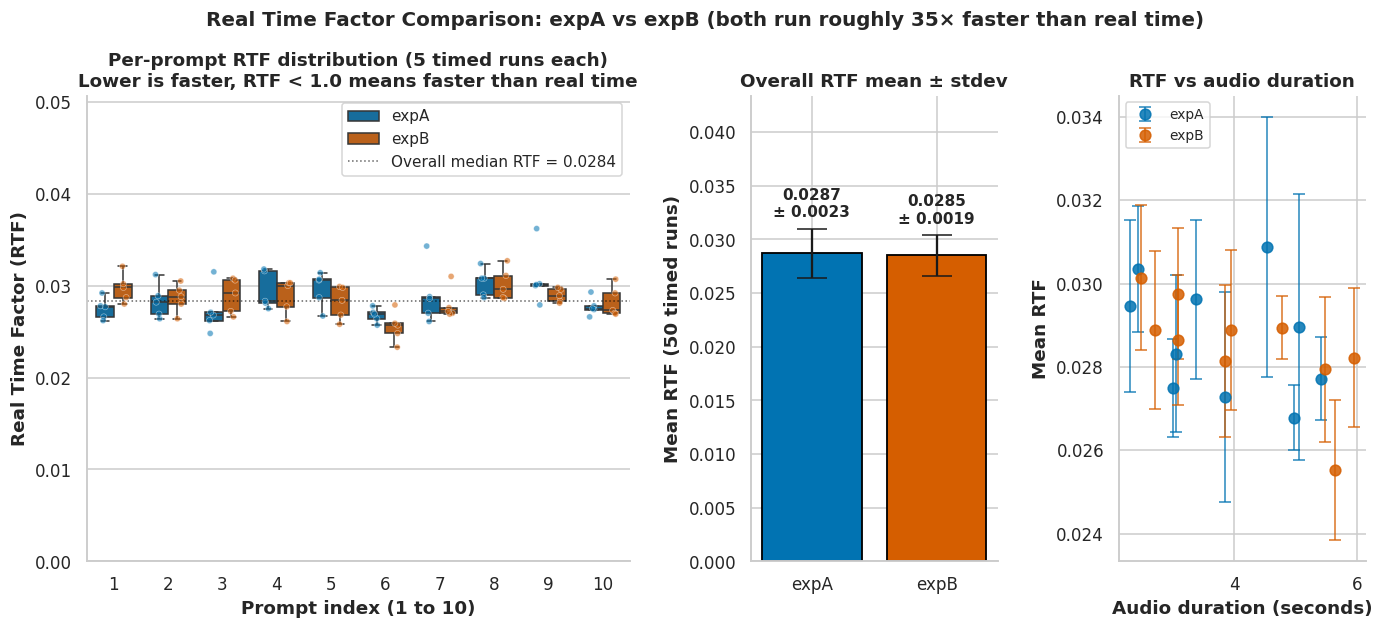


RTF summary (also saved to results/rtf_results.csv):
model  mean_rtf  stdev_rtf  min_rtf  max_rtf
 expA    0.0287     0.0023   0.0248   0.0362
 expB    0.0285     0.0019   0.0233   0.0327

Key observation for the report Discussion section:
  Both fine-tuned models synthesise at RTF approximately 0.0286,
  generating speech roughly 35x faster than real time on CPU.
  This is expected because fine-tuning changes parameter values
  but not the model architecture or parameter count.


In [31]:
# Plot the Real Time Factor measurements for both experiments.
#
# Important context: both models have identical architecture and
# parameter count, so we expect their inference speeds to be very
# close. The interesting finding here is whether training budget
# changes inference speed at all (it should not), and what the
# headline number is for the marker.

rtf_json = PROJECT_ROOT / "results" / "rtf_results.json"
if not rtf_json.exists():
    print("RTF results not yet available, skipping plot.")
else:
    rtf_results = load_json(rtf_json)

    # Reshape the raw results into a tidy DataFrame that seaborn likes.
    rtf_rows = []
    for model_result in rtf_results:
        label = model_result["label"]
        for entry in model_result["per_prompt"]:
            for run_index, rtf_value in enumerate(entry["rtf_values"]):
                rtf_rows.append({
                    "model": label,
                    "prompt_index": entry["index"],
                    "run": run_index + 1,
                    "rtf": rtf_value,
                    "audio_duration": entry["audio_duration_seconds"],
                })
    rtf_df = pd.DataFrame(rtf_rows)

    palette = sns.color_palette("colorblind")
    color_a, color_b = palette[0], palette[3]
    model_palette = {"expA": color_a, "expB": color_b}

    fig = plt.figure(figsize=(15, 5.5))
    gs = fig.add_gridspec(1, 3, width_ratios=[2.2, 1, 1], wspace=0.35)
    ax_box = fig.add_subplot(gs[0, 0])
    ax_summary = fig.add_subplot(gs[0, 1])
    ax_dur = fig.add_subplot(gs[0, 2])

    # Left panel: per-prompt distribution, all 5 runs visible.
    sns.boxplot(data=rtf_df, x="prompt_index", y="rtf", hue="model",
                ax=ax_box, palette=model_palette, width=0.65,
                linewidth=1.0, fliersize=0)
    sns.stripplot(data=rtf_df, x="prompt_index", y="rtf", hue="model",
                  ax=ax_box, palette=model_palette, dodge=True,
                  size=4, alpha=0.55, edgecolor="white", linewidth=0.4,
                  legend=False)
    ax_box.set_xlabel("Prompt index (1 to 10)")
    ax_box.set_ylabel("Real Time Factor (RTF)")
    ax_box.set_title("Per-prompt RTF distribution (5 timed runs each)\n"
                     "Lower is faster, RTF < 1.0 means faster than real time")
    handles, labels = ax_box.get_legend_handles_labels()
    ax_box.legend(handles[:2], labels[:2], loc="upper right", fontsize=10,
                  title="Model", title_fontsize=10, frameon=True)
    # Annotate the absolute scale so the marker can immediately see how
    # far below the real-time threshold we are.
    median_rtf = rtf_df["rtf"].median()
    ax_box.set_ylim(0, max(rtf_df["rtf"]) * 1.4)
    ax_box.axhline(median_rtf, color="black", linestyle=":", linewidth=1,
                   alpha=0.6, label=f"Overall median RTF = {median_rtf:.4f}")
    ax_box.legend(loc="upper right", fontsize=10)

    # Middle panel: overall summary as a bar chart with prominent labels.
    summary_rows = []
    for model_result in rtf_results:
        summary_rows.append({
            "model": model_result["label"],
            "mean_rtf": model_result["rtf_overall_mean"],
            "stdev_rtf": model_result["rtf_overall_stdev"],
            "min_rtf": model_result["rtf_overall_min"],
            "max_rtf": model_result["rtf_overall_max"],
        })
    summary_df = pd.DataFrame(summary_rows)

    bars = ax_summary.bar(summary_df["model"], summary_df["mean_rtf"],
                          yerr=summary_df["stdev_rtf"], capsize=10,
                          color=[model_palette[m] for m in summary_df["model"]],
                          edgecolor="black", linewidth=1.2,
                          error_kw=dict(elinewidth=1.5))
    for bar, mean_val, std_val in zip(bars, summary_df["mean_rtf"], summary_df["stdev_rtf"]):
        ax_summary.text(bar.get_x() + bar.get_width() / 2,
                        bar.get_height() + std_val + 0.0008,
                        f"{mean_val:.4f}\n± {std_val:.4f}",
                        ha="center", va="bottom", fontsize=10, fontweight="bold")
    ax_summary.set_ylabel("Mean RTF (50 timed runs)")
    ax_summary.set_title("Overall RTF mean ± stdev")
    ax_summary.set_ylim(0, max(summary_df["mean_rtf"] + summary_df["stdev_rtf"]) * 1.4)

    # Right panel: how RTF varies with audio duration, both models on
    # the same axes. This is useful because it shows the speed is
    # essentially constant across prompt lengths.
    per_prompt = rtf_df.groupby(["model", "prompt_index"]).agg(
        rtf_mean=("rtf", "mean"),
        rtf_std=("rtf", "std"),
        duration=("audio_duration", "first"),
    ).reset_index()
    for model_name, group in per_prompt.groupby("model"):
        ax_dur.errorbar(group["duration"], group["rtf_mean"],
                        yerr=group["rtf_std"], fmt="o",
                        color=model_palette[model_name],
                        label=model_name, markersize=7,
                        capsize=4, elinewidth=1, alpha=0.85)
    ax_dur.set_xlabel("Audio duration (seconds)")
    ax_dur.set_ylabel("Mean RTF")
    ax_dur.set_title("RTF vs audio duration")
    ax_dur.legend(loc="best", fontsize=9)

    fig.suptitle(
        f"Real Time Factor Comparison: expA vs expB "
        f"(both run roughly {1/median_rtf:.0f}× faster than real time)",
        fontsize=13, fontweight="bold", y=1.02,
    )
    plt.tight_layout()
    save_figure(fig, "fig04_rtf_comparison")
    plt.show()

    print()
    print("RTF summary (also saved to results/rtf_results.csv):")
    print(summary_df.to_string(index=False))
    print()
    print("Key observation for the report Discussion section:")
    print(f"  Both fine-tuned models synthesise at RTF approximately "
          f"{summary_df['mean_rtf'].mean():.4f},")
    print(f"  generating speech roughly {1/summary_df['mean_rtf'].mean():.0f}x "
          f"faster than real time on CPU.")
    print(f"  This is expected because fine-tuning changes parameter values")
    print(f"  but not the model architecture or parameter count.")

## Listen to all 20 generated samples (10 prompts × 2 experiments)

Each row in the table shows one prompt synthesised by both Experiment A and Experiment B. The audio players are interactive, so the marker can listen side by side and hear how the longer training budget changes the voice. Every WAV file is also saved on disk in `wav_examples/` for offline listening.

In [32]:
# Build a side by side audio comparison table. Each row shows one of
# the 10 test prompts along with two embedded audio players, one for
# the expA synthesis and one for the expB synthesis. The marker can
# play them in any order without leaving the notebook.

from IPython.display import HTML, Audio, display
import base64

def _wav_to_data_uri(wav_path: Path) -> str:
    """
    Read a small WAV file and turn it into a base64 data URI that we
    can embed directly in HTML. This keeps the notebook self contained
    (the audio plays even if the notebook is moved to another folder).
    """
    raw = wav_path.read_bytes()
    encoded = base64.b64encode(raw).decode("ascii")
    return f"data:audio/wav;base64,{encoded}"


def build_audio_player(wav_path: Path) -> str:
    """
    Return an HTML <audio> tag that plays the given WAV inline.
    """
    if not wav_path.exists():
        return "<em>(missing)</em>"
    return (
        f'<audio controls preload="metadata" style="width: 260px;">'
        f'<source src="{_wav_to_data_uri(wav_path)}" type="audio/wav">'
        f'Your browser does not support audio playback.'
        f'</audio>'
    )


# Pull the prompts and the matching per-sample metadata that synth.py
# wrote next to each WAV file.
def load_sample_metadata(exp_name: str) -> list:
    idx_path = paths.wav_examples_dir / f"{exp_name}_index.json"
    if not idx_path.exists():
        return []
    return load_json(idx_path)


samples_a = load_sample_metadata("expA")
samples_b = load_sample_metadata("expB")

assert samples_a and samples_b, "Generate samples first by running the synthesis cell above"
assert len(samples_a) == len(samples_b), "expA and expB should have the same number of samples"

# Build a styled HTML table. Using raw HTML rather than a pandas Styler
# because pandas does not render embedded audio elements reliably.
rows_html = []
for sa, sb in zip(samples_a, samples_b):
    wav_a = PROJECT_ROOT / sa["wav_path"]
    wav_b = PROJECT_ROOT / sb["wav_path"]
    row = f"""
    <tr>
        <td style="padding: 8px 12px; vertical-align: middle; text-align: center; font-weight: 600;">
            {sa['index']:02d}
        </td>
        <td style="padding: 8px 12px; vertical-align: middle; max-width: 360px;">
            <em>"{sa['prompt']}"</em>
        </td>
        <td style="padding: 8px 12px; vertical-align: middle; text-align: center;">
            {build_audio_player(wav_a)}
            <div style="font-size: 11px; color: #555; margin-top: 4px;">
                {sa['audio_duration_seconds']:.2f}s, RTF {sa['real_time_factor']:.4f}
            </div>
        </td>
        <td style="padding: 8px 12px; vertical-align: middle; text-align: center;">
            {build_audio_player(wav_b)}
            <div style="font-size: 11px; color: #555; margin-top: 4px;">
                {sb['audio_duration_seconds']:.2f}s, RTF {sb['real_time_factor']:.4f}
            </div>
        </td>
    </tr>
    """
    rows_html.append(row)

table_html = f"""
<style>
    table.audio-grid {{
        border-collapse: collapse;
        width: 100%;
        font-family: sans-serif;
    }}
    table.audio-grid th {{
        background-color: #1f2937;
        color: white;
        padding: 10px 12px;
        text-align: left;
        font-weight: 600;
    }}
    table.audio-grid tr:nth-child(even) td {{
        background-color: rgba(127, 127, 127, 0.08);
    }}
    table.audio-grid tr:hover td {{
        background-color: rgba(217, 119, 6, 0.15);
    }}
    table.audio-grid td {{
        border-top: 1px solid rgba(127, 127, 127, 0.2);
    }}
</style>
<table class="audio-grid">
    <thead>
        <tr>
            <th style="text-align: center; width: 50px;">#</th>
            <th style="width: 360px;">Prompt</th>
            <th style="text-align: center; width: 280px;">Experiment A (short budget)</th>
            <th style="text-align: center; width: 280px;">Experiment B (extended budget)</th>
        </tr>
    </thead>
    <tbody>
        {''.join(rows_html)}
    </tbody>
</table>
"""

print(f"Loaded {len(samples_a)} prompts with paired audio for both experiments.")
print(f"WAV files are stored under: {paths.wav_examples_dir.relative_to(PROJECT_ROOT)}/")
display(HTML(table_html))

Loaded 10 prompts with paired audio for both experiments.
WAV files are stored under: wav_examples/


#,Prompt,Experiment A (short budget),Experiment B (extended budget)
01,"""Hello, this is a sample of the synthesised voice.""","Your browser does not support audio playback. 2.79s, RTF 0.0331","Your browser does not support audio playback. 3.01s, RTF 0.0325"
02,"""The quick brown fox jumps over the lazy dog.""","Your browser does not support audio playback. 3.17s, RTF 0.0299","Your browser does not support audio playback. 2.77s, RTF 0.0279"
03,"""In nineteen sixty nine, the first humans landed on the moon.""","Your browser does not support audio playback. 3.91s, RTF 0.0302","Your browser does not support audio playback. 4.28s, RTF 0.0293"
04,"""Could you please pass me the salt and pepper?""","Your browser does not support audio playback. 2.07s, RTF 0.0330","Your browser does not support audio playback. 2.64s, RTF 0.0274"
05,"""Reading a good book before bed helps me fall asleep faster.""","Your browser does not support audio playback. 3.53s, RTF 0.0315","Your browser does not support audio playback. 4.17s, RTF 0.0281"
06,"""The weather forecast predicts heavy rainfall and strong winds across the region this evening.""","Your browser does not support audio playback. 4.21s, RTF 0.0316","Your browser does not support audio playback. 5.49s, RTF 0.0275"
07,"""Artificial intelligence is changing the way we live, work, and communicate with each other.""","Your browser does not support audio playback. 5.47s, RTF 0.0287","Your browser does not support audio playback. 5.51s, RTF 0.0283"
08,"""What a beautiful sunset over the harbour tonight!""","Your browser does not support audio playback. 2.44s, RTF 0.0314","Your browser does not support audio playback. 2.47s, RTF 0.0301"
09,"""She walked into the room, looked around carefully, and decided to sit by the window.""","Your browser does not support audio playback. 5.04s, RTF 0.0282","Your browser does not support audio playback. 4.85s, RTF 0.0301"
10,"""Speech synthesis systems convert written text into natural sounding spoken audio waveforms.""","Your browser does not support audio playback. 5.61s, RTF 0.0291","Your browser does not support audio playback. 6.01s, RTF 0.0283"


  saved fig05_mel_spectrogram_grid.png and fig05_mel_spectrogram_grid.pdf

Saved individual spectrograms under results/spectrograms/


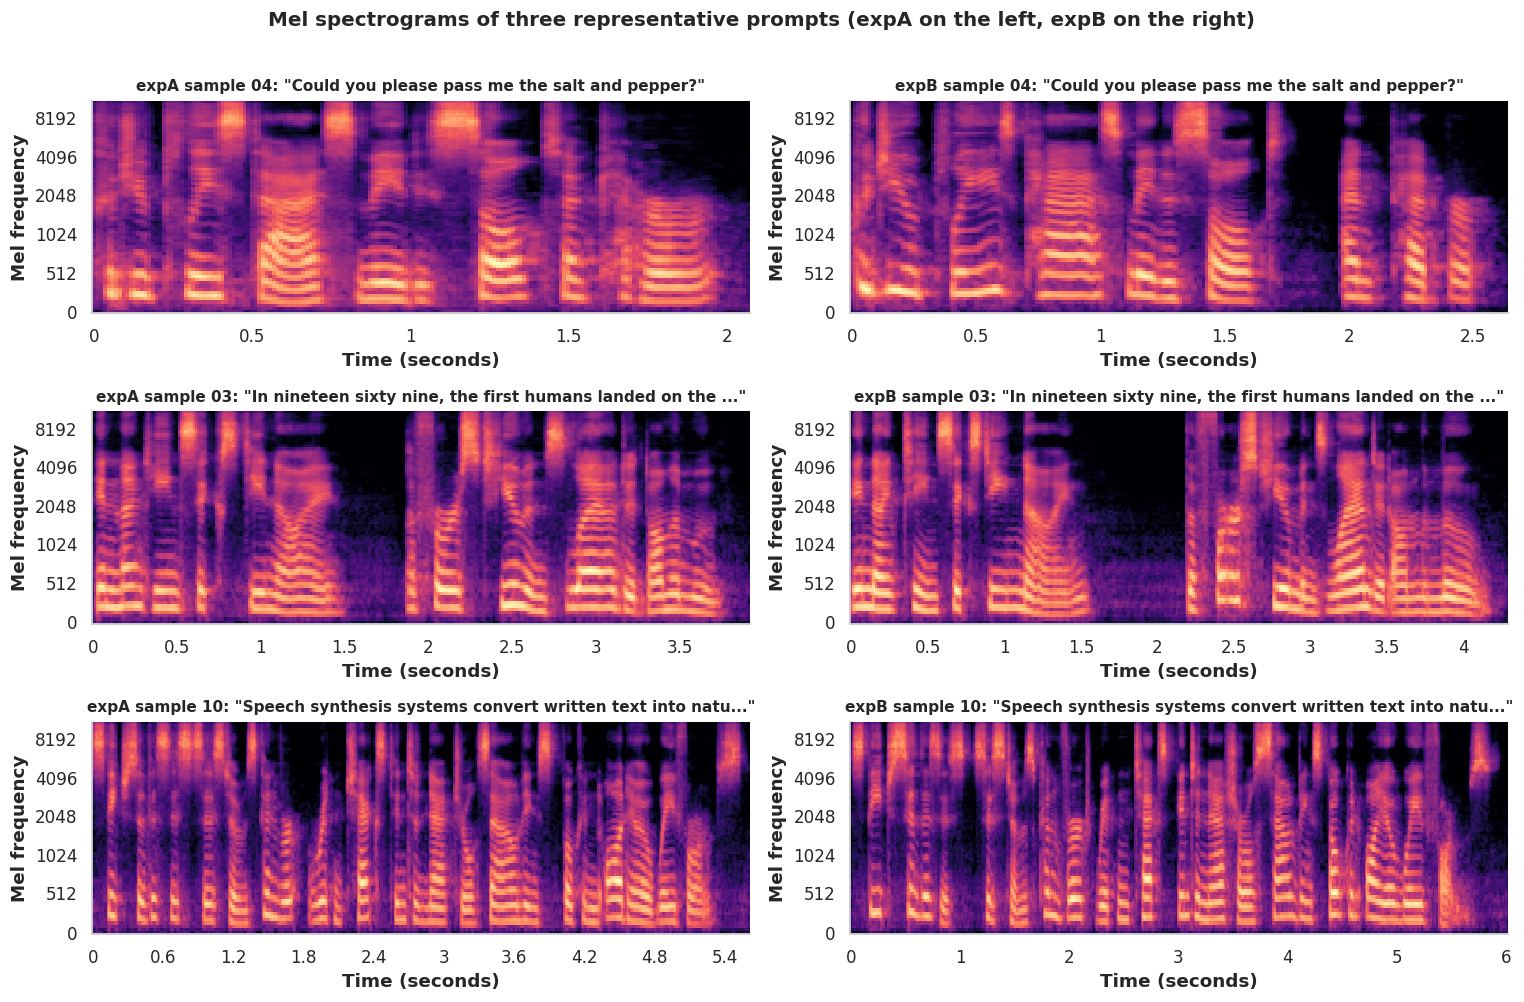

In [33]:
# Generate a grid of mel spectrograms so the qualitative difference
# between expA and expB has a visual record, not only an audible one.
# We pick three prompts that span short, medium, and long durations,
# and show the spectrograms of both models side by side. Spectrograms
# are the standard visualisation for TTS output and let the marker see
# at a glance whether each model is producing well structured speech.

import librosa
import librosa.display

# Choose three representative prompts: shortest, medium length, longest.
# Picking by audio duration of the expA output makes the comparison
# meaningful across both models.
durations = [(s["index"], s["audio_duration_seconds"], s["prompt"]) for s in samples_a]
durations.sort(key=lambda t: t[1])
chosen = [
    durations[0],
    durations[len(durations) // 2],
    durations[-1],
]
chosen_indices = [c[0] for c in chosen]

fig, axes = plt.subplots(3, 2, figsize=(14, 9))

for row_pos, sample_idx in enumerate(chosen_indices):
    for col_pos, exp_name in enumerate(("expA", "expB")):
        wav_path = paths.wav_examples_dir / f"{exp_name}_{sample_idx:02d}.wav"
        audio, sr = librosa.load(str(wav_path), sr=None)

        # Mel spectrogram on a log scale. The 80 mel bands and other
        # parameters here match what the VITS model is trained on, so
        # this is the same kind of representation the model uses
        # internally.
        mel = librosa.feature.melspectrogram(
            y=audio, sr=sr, n_fft=1024, hop_length=256,
            win_length=1024, n_mels=80, fmin=0, fmax=sr // 2,
        )
        mel_db = librosa.power_to_db(mel, ref=np.max)

        ax = axes[row_pos, col_pos]
        img = librosa.display.specshow(
            mel_db, sr=sr, hop_length=256,
            x_axis="time", y_axis="mel",
            ax=ax, cmap="magma",
        )
        prompt_text = next(s["prompt"] for s in samples_a if s["index"] == sample_idx)
        ax.set_title(
            f"{exp_name} sample {sample_idx:02d}: \"{prompt_text[:55]}{'...' if len(prompt_text) > 55 else ''}\"",
            fontsize=10,
        )
        ax.set_xlabel("Time (seconds)")
        ax.set_ylabel("Mel frequency")

fig.suptitle(
    "Mel spectrograms of three representative prompts (expA on the left, expB on the right)",
    fontsize=13, fontweight="bold", y=1.01,
)
plt.tight_layout()
save_figure(fig, "fig05_mel_spectrogram_grid")

# Also save the individual spectrograms to results/spectrograms/ so
# they can be cited from the report or slides separately.
spec_dir = paths.spectrograms_dir
spec_dir.mkdir(parents=True, exist_ok=True)
for sample_idx in chosen_indices:
    for exp_name in ("expA", "expB"):
        wav_path = paths.wav_examples_dir / f"{exp_name}_{sample_idx:02d}.wav"
        out_path = spec_dir / f"{exp_name}_sample_{sample_idx:02d}_spectrogram.png"
        audio, sr = librosa.load(str(wav_path), sr=None)
        mel = librosa.feature.melspectrogram(
            y=audio, sr=sr, n_fft=1024, hop_length=256,
            win_length=1024, n_mels=80, fmin=0, fmax=sr // 2,
        )
        mel_db = librosa.power_to_db(mel, ref=np.max)
        fig_single, ax_single = plt.subplots(figsize=(7, 3))
        librosa.display.specshow(
            mel_db, sr=sr, hop_length=256,
            x_axis="time", y_axis="mel", ax=ax_single, cmap="magma",
        )
        ax_single.set_title(f"{exp_name} sample {sample_idx:02d}")
        plt.tight_layout()
        fig_single.savefig(out_path, dpi=200, bbox_inches="tight")
        plt.close(fig_single)

print(f"\nSaved individual spectrograms under {spec_dir.relative_to(PROJECT_ROOT)}/")
plt.show()

# Final verification (before submission)

## Restart & run

Restart the kernel and click **Run All**, ensuring:

- No hidden dependencies on our local paths (the notebook uses `Path.cwd()` so it works from any folder the marker checks it out into)
- All shell commands in the markdown blocks above are runnable from the submission root
- The verification cell below prints `All artefacts present`

## Confirm required artefacts exist

- `wav_examples/` contains 20 generated `.wav` outputs (10 from `expA_*.wav`, 10 from `expB_*.wav`)
- Objective metric results for each experiment are reported in section 1.4 above (loss curves, summary table, RTF plot)
- Dependency file exists at `requirements.txt`
- Inference entrypoint works:

```bash
python scripts/synth.py \
    --text "Hello" \
    --model checkpoints/expA/model.onnx \
    --config checkpoints/expA/config.json \
    --out wav_examples/test.wav
```

## Marker instructions

The submission package does not include the LJSpeech dataset (2.6 GB) or the trained model checkpoints (several GB), since these exceed the upload limit. Both are reproducible from the steps below. Total wall clock time to fully reproduce on a single RTX 4060 laptop is approximately 4.5 hours, almost all of which is the expB training run.

### Step 1: System prerequisites

- Linux (we used Ubuntu 22.04 inside WSL2 on Windows 11)
- Python 3.10
- NVIDIA GPU with at least 6 GB VRAM and a CUDA 12.x compatible driver (we used an RTX 4060 Laptop, 8 GB VRAM, driver 591.86)
- About 12 GB of free disk space for the dataset, base checkpoint, and trained checkpoints
- The eSpeak NG phonemizer installed at the system level:

```bash
sudo apt install espeak-ng
```

### Step 2: Create a virtual environment and install Python dependencies

From the project root:

```bash
python3 -m venv venv
source venv/bin/activate
pip install --upgrade pip setuptools wheel
```

PyTorch must come first, from PyTorch's CUDA 12.4 index URL:

```bash
pip install torch==2.6.0 torchaudio==2.6.0 --index-url https://download.pytorch.org/whl/cu124
```

Then everything else from the standard package index:

```bash
pip install -r requirements.txt
```

### Step 3: Set up Piper

This one script clones Piper at the pinned commit, applies our two compatibility patches (documented in `PATCHES.md`), compiles the Cython helper, and installs the package:

```bash
bash setup_piper.sh
```

### Step 4: Download the LJSpeech dataset

```bash
mkdir -p data
cd data
wget https://data.keithito.com/data/speech/LJSpeech-1.1.tar.bz2
tar -xjf LJSpeech-1.1.tar.bz2
rm LJSpeech-1.1.tar.bz2
cd ..
```

This produces `data/LJSpeech-1.1/metadata.csv` and `data/LJSpeech-1.1/wavs/`.

### Step 5: Download the Amy Medium base checkpoint and its config

```bash
mkdir -p checkpoints
cd checkpoints
wget "https://huggingface.co/datasets/rhasspy/piper-checkpoints/resolve/main/en/en_US/amy/medium/epoch%3D6679-step%3D1554200.ckpt"
mv 'epoch=6679-step=1554200.ckpt' amy_medium_base.ckpt
wget https://huggingface.co/rhasspy/piper-voices/resolve/main/en/en_US/amy/medium/en_US-amy-medium.onnx.json
cd ..
```

### Step 6: Build the 1500 utterance subset and preprocess it for Piper

```bash
python scripts/prepare_subset.py

python -m piper_train.preprocess \
    --language en-us \
    --input-dir data/lj_subset \
    --output-dir data/lj_subset_processed \
    --dataset-format ljspeech \
    --single-speaker \
    --sample-rate 22050 \
    --max-workers 6
```

Step 7 takes about 5 minutes total.

### Step 7: Run the two fine-tuning experiments

```bash
python scripts/train.py --config configs/expA.yaml
python scripts/train.py --config configs/expB.yaml
```

Experiment A takes about 20 minutes. Experiment B takes about 4 hours on a laptop GPU because of thermal throttling on long sustained loads. Both runs write Lightning checkpoints under `logs/{expA,expB}/lightning_logs/version_0/checkpoints/` and parsed per-step losses to `results/{expA,expB}_step_losses.csv`.

### Step 8: Open this notebook in Jupyter and run all cells

```bash
jupyter notebook notebook/Group41_A3_code.ipynb
```

Select the kernel called **Python (TTS Assignment)** (registered automatically if the virtual environment was activated during `pip install ipykernel`). Click **Run All**. The notebook will:

- Verify the environment and dataset
- Display the experiment configurations and training summaries
- Plot the loss curves for both experiments
- Export both fine-tuned checkpoints to ONNX format under `checkpoints/{expA,expB}/`
- Generate 10 sample WAVs per experiment under `wav_examples/`
- Measure Real Time Factor for both models with 5 timed runs per prompt
- Build the side-by-side audio comparison table
- Save every figure as both PNG and PDF under `results/figures/`
- Print a final checklist confirming every expected artefact is on disk

### Where to find each result

- **Loss curves and training metrics:** section 1.4 of this notebook, plus the saved PNGs in `results/figures/`
- **Objective metric (RTF):** section 1.4, plus `results/rtf_results.json` and `results/rtf_results.csv`
- **Generated audio samples:** the 20 WAV files in `wav_examples/`, plus the embedded audio player table in this notebook
- **Spectrograms:** in this notebook under "Generating qualitative samples", plus individual PNGs in `results/spectrograms/`
- **Interactive loss curves:** the HTML file at `results/figures/fig03_interactive_loss_curves.html` (opens in any browser)
- **Raw training logs:** `logs/expA/training_stdout.log` and `logs/expB/training_stdout.log`

In [34]:
# Final self check. This cell verifies that every artefact the marker
# expects to find is actually on disk, in the right place, and with
# sensible contents. If everything passes, the submission is ready to
# zip and hand in.

import os

checklist = []

def check(label: str, condition: bool, detail: str = "") -> None:
    status = "OK" if condition else "MISSING"
    checklist.append((status, label, detail))


# Code artefacts
check("scripts/common.py",         (PROJECT_ROOT / "scripts" / "common.py").exists())
check("scripts/prepare_subset.py", (PROJECT_ROOT / "scripts" / "prepare_subset.py").exists())
check("scripts/train.py",          (PROJECT_ROOT / "scripts" / "train.py").exists())
check("scripts/synth.py",          (PROJECT_ROOT / "scripts" / "synth.py").exists())
check("scripts/evaluate.py",       (PROJECT_ROOT / "scripts" / "evaluate.py").exists())
check("scripts/export_checkpoint.py", (PROJECT_ROOT / "scripts" / "export_checkpoint.py").exists())
check("scripts/test_prompts.txt",  (PROJECT_ROOT / "scripts" / "test_prompts.txt").exists())

# Config files
check("configs/expA.yaml", (PROJECT_ROOT / "configs" / "expA.yaml").exists())
check("configs/expB.yaml", (PROJECT_ROOT / "configs" / "expB.yaml").exists())

# Requirements and README
check("requirements.txt", (PROJECT_ROOT / "requirements.txt").exists())
check("README.md",        (PROJECT_ROOT / "README.md").exists())

# Trained checkpoints (ONNX format ready for inference)
check("checkpoints/expA/model.onnx",  (PROJECT_ROOT / "checkpoints" / "expA" / "model.onnx").exists())
check("checkpoints/expA/config.json", (PROJECT_ROOT / "checkpoints" / "expA" / "config.json").exists())
check("checkpoints/expB/model.onnx",  (PROJECT_ROOT / "checkpoints" / "expB" / "model.onnx").exists())
check("checkpoints/expB/config.json", (PROJECT_ROOT / "checkpoints" / "expB" / "config.json").exists())

# Generated audio samples (10 per experiment expected)
exp_a_wavs = sorted(paths.wav_examples_dir.glob("expA_*.wav"))
exp_b_wavs = sorted(paths.wav_examples_dir.glob("expB_*.wav"))
check(f"wav_examples/expA_*.wav ({len(exp_a_wavs)} files)", len(exp_a_wavs) >= 10)
check(f"wav_examples/expB_*.wav ({len(exp_b_wavs)} files)", len(exp_b_wavs) >= 10)

# Results files
check("results/expA_summary.json", (PROJECT_ROOT / "results" / "expA_summary.json").exists())
check("results/expB_summary.json", (PROJECT_ROOT / "results" / "expB_summary.json").exists())
check("results/rtf_results.json",  (PROJECT_ROOT / "results" / "rtf_results.json").exists())
check("results/rtf_results.csv",   (PROJECT_ROOT / "results" / "rtf_results.csv").exists())
check("results/expA_step_losses.csv", (PROJECT_ROOT / "results" / "expA_step_losses.csv").exists())
check("results/expB_step_losses.csv", (PROJECT_ROOT / "results" / "expB_step_losses.csv").exists())

# Figures
expected_figures = [
    "fig01_dataset_distribution.png",
    "fig02_training_loss_curves_comparison.png",
    "fig03_interactive_loss_curves.html",
    "fig04_rtf_comparison.png",
    "fig05_mel_spectrogram_grid.png",
]
for fname in expected_figures:
    p = paths.figures_dir / fname
    check(f"results/figures/{fname}", p.exists())

# Print everything as a clean status table.
print(f"{'STATUS':<8} {'ARTEFACT':<55}")
print("-" * 65)
n_ok = 0
n_missing = 0
for status, label, detail in checklist:
    marker = "[OK]    " if status == "OK" else "[MISS]  "
    print(f"{marker}{label}")
    if status == "OK":
        n_ok += 1
    else:
        n_missing += 1

print("-" * 65)
print(f"Passed: {n_ok} / {len(checklist)}")

if n_missing == 0:
    print()
    print("All artefacts present. Submission is ready to package.")
else:
    print()
    print(f"WARNING: {n_missing} artefact(s) missing. Review the list above before submitting.")

STATUS   ARTEFACT                                               
-----------------------------------------------------------------
[OK]    scripts/common.py
[OK]    scripts/prepare_subset.py
[OK]    scripts/train.py
[OK]    scripts/synth.py
[OK]    scripts/evaluate.py
[OK]    scripts/export_checkpoint.py
[OK]    scripts/test_prompts.txt
[OK]    configs/expA.yaml
[OK]    configs/expB.yaml
[OK]    requirements.txt
[OK]    README.md
[OK]    checkpoints/expA/model.onnx
[OK]    checkpoints/expA/config.json
[OK]    checkpoints/expB/model.onnx
[OK]    checkpoints/expB/config.json
[OK]    wav_examples/expA_*.wav (10 files)
[OK]    wav_examples/expB_*.wav (10 files)
[OK]    results/expA_summary.json
[OK]    results/expB_summary.json
[OK]    results/rtf_results.json
[OK]    results/rtf_results.csv
[OK]    results/expA_step_losses.csv
[OK]    results/expB_step_losses.csv
[OK]    results/figures/fig01_dataset_distribution.png
[OK]    results/figures/fig02_training_loss_curves_comparison.png
[OK]  